# regressão linear

**objetivo:** prever `charges` com regressão linear e comparar especificações alinhadas ao eda

**considerações**
- remover duplicata
- usar `log1p(charges)` como target candidata principal
- manter baseline simples com `age`, `bmi`, `smoker_yes`
- testar expansão com `children`, `sex`, `region`, interação `bmi_x_smoker`, curvatura de idade (`age_sq`) e efeito de pico jovem (`is_18_19`)
- comparar todos os modelos na mesma escala de negócio (`charges`)

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.anova import anova_lm
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from IPython.display import display

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

In [2]:
df_raw = pd.read_csv("../data/insurance.csv").copy()
rows_raw = len(df_raw)

df = df_raw.drop_duplicates().copy()
rows_clean = len(df)

# features derivadas usadas no eda
if "smoker_yes" not in df.columns:
    df["smoker_yes"] = (df["smoker"] == "yes").astype(int)
if "log_charges" not in df.columns:
    df["log_charges"] = np.log1p(df["charges"])

df["bmi_x_smoker"] = df["bmi"] * df["smoker_yes"]
df["age_sq"] = df["age"] ** 2
df["is_18_19"] = df["age"].isin([18, 19]).astype(int)

print(f"linhas no arquivo bruto: {rows_raw}")
print(f"linhas após remover duplicatas: {rows_clean}")
print(f"duplicatas removidas: {rows_raw - rows_clean}")

df[["age", "age_sq", "is_18_19", "bmi", "children", "smoker", "smoker_yes", "bmi_x_smoker", "charges", "log_charges"]].head()

linhas no arquivo bruto: 1338
linhas após remover duplicatas: 1337
duplicatas removidas: 1


,age,age_sq,is_18_19,bmi,children,smoker,smoker_yes,bmi_x_smoker,charges,log_charges
0,19,361,1,27.9000,0,yes,1,27.9000,"16,884.9240",9.7342
1,18,324,1,33.7700,1,no,0,0.0000,"1,725.5523",7.4539
2,28,784,0,33.0000,3,no,0,0.0000,"4,449.4620",8.4008
3,33,1089,0,22.7050,0,no,0,0.0000,"21,984.4706",9.9981
4,32,1024,0,28.8800,0,no,0,0.0000,"3,866.8552",8.2605


transformação dos achados do eda em variáveis de modelagem<br>
- base deduplicada para evitar viés por registros repetidos<br>
- `smoker_yes` permite uso direto da informação de tabagismo em regressão linear<br>
- `log_charges` reduz a assimetria da variável-alvo e ajuda a estabilizar a variância<br>
- `bmi_x_smoker` captura o efeito combinado de IMC e tabagismo<br>
- `age_sq` permite modelar curvatura da idade<br>
- `is_18_19` incorpora explicitamente o pico etário identificado no eda<br>

## 1. split treino e teste

usei `stratify=smoker_yes` para manter a proporção de fumantes entre treino e teste

In [3]:
train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df["smoker_yes"]
)

print(f"Treino: {train_df.shape}")
print(f"Teste: {test_df.shape}")
print()
print(f"proporção smoker_yes no dataset: {df['smoker_yes'].mean():.4f}")
print(f"proporção smoker_yes no treino:  {train_df['smoker_yes'].mean():.4f}")
print(f"proporção smoker_yes no teste:   {test_df['smoker_yes'].mean():.4f}")

Treino: (1069, 12)
Teste: (268, 12)

proporção smoker_yes no dataset: 0.2049
proporção smoker_yes no treino:  0.2049
proporção smoker_yes no teste:   0.2052


## 2. funções de avaliação

a tabela final compara desempenho em `charges` (escala de negócio), mesmo quando o modelo é treinado em `log_charges`


In [4]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def metric_dict(y_true, y_pred):
    return {
        "RMSE": rmse(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
    }

def evaluate_formula_model(model_name, formula, target_col):
    ols = smf.ols(formula, data=train_df).fit()
    ols_hc3 = ols.get_robustcov_results(cov_type="HC3")

    pred_train_target = ols.predict(train_df)
    pred_test_target = ols.predict(test_df)

    y_train_target = train_df[target_col]
    y_test_target = test_df[target_col]

    target_metrics = pd.DataFrame([
        {"model": model_name, "split": "train", "target_scale": target_col, **metric_dict(y_train_target, pred_train_target)},
        {"model": model_name, "split": "test", "target_scale": target_col, **metric_dict(y_test_target, pred_test_target)},
    ])

    if target_col == "log_charges":
        pred_train_charges = np.clip(np.expm1(pred_train_target), a_min=0, a_max=None)
        pred_test_charges = np.clip(np.expm1(pred_test_target), a_min=0, a_max=None)
    else:
        pred_train_charges = pred_train_target
        pred_test_charges = pred_test_target

    business_metrics = pd.DataFrame([
        {"model": model_name, "split": "train", "eval_scale": "charges", **metric_dict(train_df["charges"], pred_train_charges)},
        {"model": model_name, "split": "test", "eval_scale": "charges", **metric_dict(test_df["charges"], pred_test_charges)},
    ])

    pred_test = pd.DataFrame({
        "model": model_name,
        "charges_real": test_df["charges"].values,
        "charges_predito": pred_test_charges,
    })
    pred_test["residuo"] = pred_test["charges_real"] - pred_test["charges_predito"]

    bp_lm, bp_lm_p, bp_f, bp_f_p = het_breuschpagan(ols.resid, ols.model.exog)

    bp_table = pd.DataFrame([
        {
            "model": model_name,
            "target_scale": target_col,
            "bp_lm_stat": bp_lm,
            "bp_lm_p_value": bp_lm_p,
            "bp_f_stat": bp_f,
            "bp_f_p_value": bp_f_p,
        }
    ])

    return {
        "name": model_name,
        "formula": formula,
        "target": target_col,
        "ols": ols,
        "ols_hc3": ols_hc3,
        "target_metrics": target_metrics,
        "business_metrics": business_metrics,
        "pred_test": pred_test,
        "bp": bp_table,
    }


def hc3_coef_table(ols_model, ols_hc3):
    terms = ols_model.model.exog_names
    conf = ols_hc3.conf_int()

    return pd.DataFrame({
        "term": terms,
        "coef": np.asarray(ols_hc3.params),
        "p_value_hc3": np.asarray(ols_hc3.pvalues),
        "ci_low": conf[:, 0],
        "ci_high": conf[:, 1],
    })

tmp = evaluate_formula_model(
    model_name="teste",
    formula="charges ~ age + bmi + smoker_yes",
    target_col="charges"
)

display(tmp["target_metrics"])
display(tmp["business_metrics"])
display(tmp["bp"])

,model,split,target_scale,RMSE,MAE,R2
0,teste,train,charges,"6,329.3621","4,383.7755",0.7277
1,teste,test,charges,"5,002.2242","3,592.7740",0.8264


,model,split,eval_scale,RMSE,MAE,R2
0,teste,train,charges,"6,329.3621","4,383.7755",0.7277
1,teste,test,charges,"5,002.2242","3,592.7740",0.8264


,model,target_scale,bp_lm_stat,bp_lm_p_value,bp_f_stat,bp_f_p_value
0,teste,charges,83.2375,0.0000,29.9761,0.0000


- esse bloco confirma que a função de avaliação está ok, ela retorna métricas de desempenho (`rmse`, `mae`, `r2`) e também o diagnóstico de heterocedasticidade (`breusch-pagan`)
- como aqui a target foi `charges`, `target_metrics` e `business_metrics` ficaram iguais. (quando a target for `log_charges`, a comparação de negócio continua em `charges` após `expm1`)
- o resultado do modelo teste foi bom para baseline (`r2` de teste ~0.83), mas o `breusch-pagan` com `p-value` ~0 mostra heterocedasticidade
- por isso, faz sentido manter erros robustos (`hc3`) na inferência e comparar com modelos em `log_charges` nas próximas etapas

## 3. experimentos alinhados ao eda

modelos comparados
1. `M1_raw_baseline`: `charges ~ age + bmi + smoker_yes`
2. `M2_log_baseline`: `log_charges ~ age + bmi + smoker_yes`
3. `M3_log_expandido_sem_interacao`: adiciona `children + sex + region`
4. `M4_log_expandido_com_interacao`: adiciona `bmi_x_smoker`
5. `M5_log_expandido_age_quad`: adiciona curvatura de idade (`age_sq`)
6. `M6_log_expandido_age_quad_peak`: adiciona também `is_18_19`

In [5]:
experiments = [
    {
        "model": "M1_raw_baseline",
        "formula": "charges ~ age + bmi + smoker_yes",
        "target": "charges",
    },
    {
        "model": "M2_log_baseline",
        "formula": "log_charges ~ age + bmi + smoker_yes",
        "target": "log_charges",
    },
    {
        "model": "M3_log_expandido_sem_interacao",
        "formula": "log_charges ~ age + bmi + children + smoker_yes + C(sex) + C(region)",
        "target": "log_charges",
    },
    {
        "model": "M4_log_expandido_com_interacao",
        "formula": "log_charges ~ age + bmi + children + smoker_yes + bmi_x_smoker + C(sex) + C(region)",
        "target": "log_charges",
    },
    {
        "model": "M5_log_expandido_age_quad",
        "formula": "log_charges ~ age + age_sq + bmi + children + smoker_yes + bmi_x_smoker + C(sex) + C(region)",
        "target": "log_charges",
    },
    {
        "model": "M6_log_expandido_age_quad_peak",
        "formula": "log_charges ~ age + age_sq + is_18_19 + bmi + children + smoker_yes + bmi_x_smoker + C(sex) + C(region)",
        "target": "log_charges",
    },
]

results = {}
for exp in experiments:
    results[exp["model"]] = evaluate_formula_model(
        model_name=exp["model"],
        formula=exp["formula"],
        target_col=exp["target"],
    )

pd.DataFrame(experiments)

,model,formula,target
0,M1_raw_baseline,charges ~ age + bmi + smoker_yes,charges
1,M2_log_baseline,log_charges ~ age + bmi + smoker_yes,log_charges
2,M3_log_expandido_sem_interacao,log_charges ~ age + bmi + children + smoker_yes + C(sex) + C(region),log_charges
3,M4_log_expandido_com_interacao,log_charges ~ age + bmi + children + smoker_yes + bmi_x_smoker + C(sex) + C(region),log_charges
4,M5_log_expandido_age_quad,log_charges ~ age + age_sq + bmi + children + smoker_yes + bmi_x_smoker + C(sex) + C(region),log_charges
5,M6_log_expandido_age_quad_peak,log_charges ~ age + age_sq + is_18_19 + bmi + children + smoker_yes + bmi_x_smoker + C(sex) + C(region),log_charges


In [6]:
metrics_target = pd.concat([v["target_metrics"] for v in results.values()], ignore_index=True)
metrics_business = pd.concat([v["business_metrics"] for v in results.values()], ignore_index=True)
bp_all = pd.concat([v["bp"] for v in results.values()], ignore_index=True)

display(metrics_target.sort_values(["split", "RMSE"]).reset_index(drop=True))

test_business = (
    metrics_business
    .query("split == 'test'")
    [["model", "RMSE", "MAE", "R2"]]
    .sort_values("RMSE")
    .reset_index(drop=True)
)

rmse_m1 = float(test_business.loc[test_business["model"] == "M1_raw_baseline", "RMSE"].iloc[0])
test_business["delta_rmse_vs_m1_pct"] = ((test_business["RMSE"] / rmse_m1) - 1) * 100

display(test_business)
display(bp_all.round(6))

,model,split,target_scale,RMSE,MAE,R2
0,M5_log_expandido_age_quad,test,log_charges,0.3439,0.2334,0.8581
1,M6_log_expandido_age_quad_peak,test,log_charges,0.3451,0.2334,0.8572
2,M4_log_expandido_com_interacao,test,log_charges,0.3481,0.2338,0.8546
3,M3_log_expandido_sem_interacao,test,log_charges,0.3680,0.2480,0.8376
4,M2_log_baseline,test,log_charges,0.3768,0.2537,0.8297
5,M1_raw_baseline,test,charges,"5,002.2242","3,592.7740",0.8264
6,M6_log_expandido_age_quad_peak,train,log_charges,0.4441,0.2831,0.7667
7,M5_log_expandido_age_quad,train,log_charges,0.4446,0.2837,0.7662
8,M4_log_expandido_com_interacao,train,log_charges,0.4458,0.2793,0.7649
9,M3_log_expandido_sem_interacao,train,log_charges,0.4600,0.2918,0.7497


,model,RMSE,MAE,R2,delta_rmse_vs_m1_pct
0,M1_raw_baseline,"5,002.2242","3,592.7740",0.8264,0.0000
1,M5_log_expandido_age_quad,"7,780.5917","3,683.9534",0.5801,55.5426
2,M6_log_expandido_age_quad_peak,"7,785.7981","3,668.1865",0.5795,55.6467
3,M2_log_baseline,"7,818.6976","3,841.8216",0.5759,56.3044
4,M3_log_expandido_sem_interacao,"7,905.9863","3,976.0188",0.5664,58.0494
5,M4_log_expandido_com_interacao,"8,003.1931","3,739.4946",0.5557,59.9927


,model,target_scale,bp_lm_stat,bp_lm_p_value,bp_f_stat,bp_f_p_value
0,M1_raw_baseline,charges,83.2375,0.0000,29.9761,0.0000
1,M2_log_baseline,log_charges,83.6389,0.0000,30.1329,0.0000
2,M3_log_expandido_sem_interacao,log_charges,65.6800,0.0000,8.6738,0.0000
3,M4_log_expandido_com_interacao,log_charges,63.6519,0.0000,7.4499,0.0000
4,M5_log_expandido_age_quad,log_charges,85.5400,0.0000,9.2023,0.0000
5,M6_log_expandido_age_quad_peak,log_charges,85.7042,0.0000,8.3753,0.0000


- aqui eu consolidei as métricas de todos os modelos e comparei o erro na escala original de `charges`
- no `metrics_target`, os modelos em `log_charges` (m5/m6) ficam melhores na própria escala log (rmse ~0.34)
- quando volto para `charges` (`test_business`), o melhor foi o `m1_raw_baseline` (rmse ~5.002). os modelos log ficaram ~55% a ~60% piores em rmse
- isso sugere que, neste setup, a transformação log melhorou ajuste na escala log, mas perdeu qualidade ao voltar para reais
- o breusch-pagan ficou com `p-value ~ 0` em todos os modelos, então ainda há heterocedasticidade (mesmo com log)

- para previsão em reais, neste momento o baseline raw está melhor
- para inferência estatística, continuo usando erro robusto (`hc3`) por causa da heterocedasticidade
- aplicar correção de retransformação (smearing) nos modelos log antes de descartar essa abordagem

## 4. bloco de avaliação comparativa (escala `charges`)

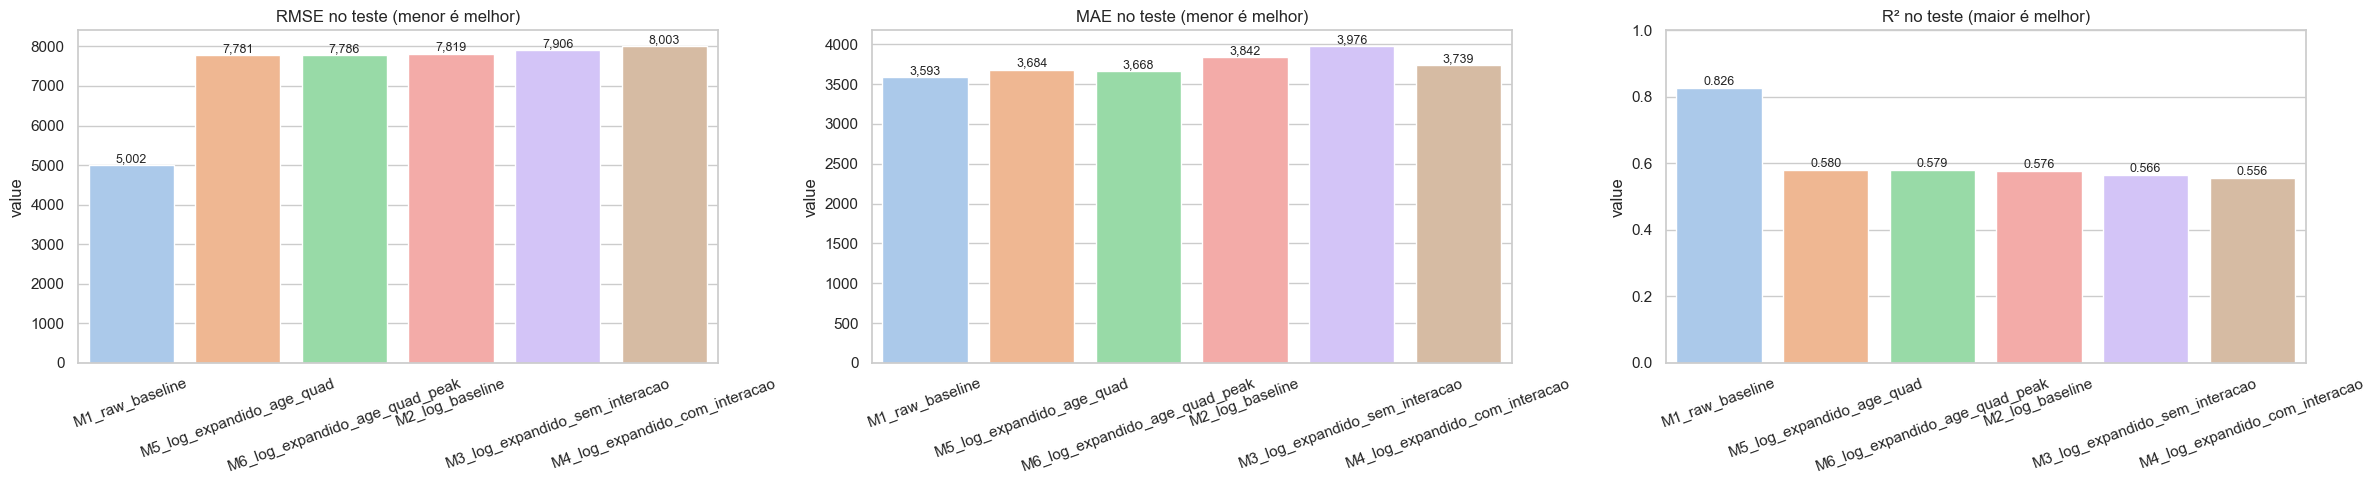

In [12]:
plot_df = test_business.melt(
    id_vars="model",
    value_vars=["RMSE", "MAE", "R2"],
    var_name="metric",
    value_name="value"
)

fig, axes = plt.subplots(1, 3, figsize=(24, 5))

# RMSE
sns.barplot(
    data=plot_df.query("metric == 'RMSE'"),
    x="model",
    y="value",
    ax=axes[0],
    palette="pastel"
)
axes[0].set_title("RMSE no teste (menor é melhor)")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=20)
for p in axes[0].patches:
    h = p.get_height()
    axes[0].annotate(
        f"{h:,.0f}",
        (p.get_x() + p.get_width() / 2, h),
        ha="center",
        va="bottom",
        fontsize=9
    )

# MAE
sns.barplot(
    data=plot_df.query("metric == 'MAE'"),
    x="model",
    y="value",
    ax=axes[1],
    palette="pastel"
)
axes[1].set_title("MAE no teste (menor é melhor)")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=20)
for p in axes[1].patches:
    h = p.get_height()
    axes[1].annotate(
        f"{h:,.0f}",
        (p.get_x() + p.get_width() / 2, h),
        ha="center",
        va="bottom",
        fontsize=9
    )

# R2
sns.barplot(
    data=plot_df.query("metric == 'R2'"),
    x="model",
    y="value",
    ax=axes[2],
    palette="pastel"
)
axes[2].set_title("R² no teste (maior é melhor)")
axes[2].set_xlabel("")
axes[2].tick_params(axis="x", rotation=20)
axes[2].set_ylim(0, 1)
for p in axes[2].patches:
    h = p.get_height()
    axes[2].annotate(
        f"{h:.3f}",
        (p.get_x() + p.get_width() / 2, h),
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

- o `m1_raw_baseline` foi o melhor nos dois critérios (rmse ~5.002 e mae ~3.593)
- os modelos treinados em `log_charges` ficaram piores após voltar para reais (`expm1`), mesmo os mais completos (`m5`/`m6`)
- entre os modelos log, `m5` e `m6` foram os menos ruins, então `age_sq` ajudou um pouco, e `is_18_19` quase não mudou o resultado
- para previsão direta em reais, esse resultado favorece manter o baseline raw como modelo principal nesta etapa

In [8]:
# testes formais incrementais (modelos aninhados)
anova_interaction = anova_lm(
    results["M3_log_expandido_sem_interacao"]["ols"],
    results["M4_log_expandido_com_interacao"]["ols"]
)

anova_age_quad = anova_lm(
    results["M4_log_expandido_com_interacao"]["ols"],
    results["M5_log_expandido_age_quad"]["ols"]
)

anova_age_peak = anova_lm(
    results["M5_log_expandido_age_quad"]["ols"],
    results["M6_log_expandido_age_quad_peak"]["ols"]
)

print("ANOVA incremental | interação BMI x smoker (M3 vs M4)")
display(anova_interaction)

print("ANOVA incremental | curvatura de idade age_sq (M4 vs M5)")
display(anova_age_quad)

print("ANOVA incremental | efeito de pico jovem is_18_19 (M5 vs M6)")
display(anova_age_peak)

ANOVA incremental | interação BMI x smoker (M3 vs M4)


,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,"1,060.0000",226.2054,0.0000,NaN,NaN,NaN
1,"1,059.0000",212.4257,1.0000,13.7797,68.6953,0.0000


ANOVA incremental | curvatura de idade age_sq (M4 vs M5)


,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,"1,059.0000",212.4257,0.0000,NaN,NaN,NaN
1,"1,058.0000",211.2954,1.0000,1.1303,5.6596,0.0175


ANOVA incremental | efeito de pico jovem is_18_19 (M5 vs M6)


,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,"1,058.0000",211.2954,0.0000,NaN,NaN,NaN
1,"1,057.0000",210.8167,1.0000,0.4787,2.4001,0.1216


- `m3 vs m4` (interação `bmi_x_smoker`) ganho forte e estatisticamente significativo (`p = 0.0000`)
  - faz sentido manter a interação no modelo, porque ela realmente melhora o ajuste

- `m4 vs m5` (`age_sq`) ganho menor, mas ainda significativo (`p = 0.0175`)
  - existe sinal de não linearidade da idade. `age_sq` pode ser útil

- `m5 vs m6` (`is_18_19`): não houve ganho estatisticamente significativo (`p = 0.1216`)
  - apesar do pico em 18-19 no eda, esse dummy não trouxe melhora clara depois que o modelo já tinha `age_sq`
<br>

- manter `bmi_x_smoker`
- manter `age_sq` se também ajudar nas métricas de previsão
- não priorizar `is_18_19` nesta versão, a menos que traga ganho em `rmse/mae` na escala de `charges`


## 5. modelo recomendado e leitura inferencial

In [9]:
best_model_name = test_business.iloc[0]["model"]
best_result = results[best_model_name]

print(f"modelo com menor RMSE no teste: {best_model_name}")
print(f"fórmula: {best_result['formula']}")
print(f"target de treino: {best_result['target']}")

coef_best = hc3_coef_table(best_result["ols"], best_result["ols_hc3"])    .sort_values("p_value_hc3")

display(coef_best)

modelo com menor RMSE no teste: M1_raw_baseline
fórmula: charges ~ age + bmi + smoker_yes
target de treino: charges


,term,coef,p_value_hc3,ci_low,ci_high
3,smoker_yes,"23,696.6607",0.0000,"22,401.5245","24,991.7970"
1,age,259.0895,0.0000,231.9000,286.2790
0,Intercept,"-11,132.6907",0.0000,"-13,405.6347","-8,859.7467"
2,bmi,308.6324,0.0000,241.3208,375.9439


- aqui eu seleciono o modelo com menor `rmse` no teste, para garantir decisão orientada por desempenho
- nesse caso, o melhor foi o `M1_raw_baseline` (`charges ~ age + bmi + smoker_yes`), então o baseline simples já performou melhor que as versões expandidas
- a tabela de coeficientes HC3 mostra que `smoker_yes`, `age` e `bmi` ficaram estatisticamente significativos (`p_value_hc3` muito baixo), com intervalos de confiança que não cruzam zero
- ser fumante aumenta muito o custo previsto. idade e imc também aumentam `charges` de forma consistente

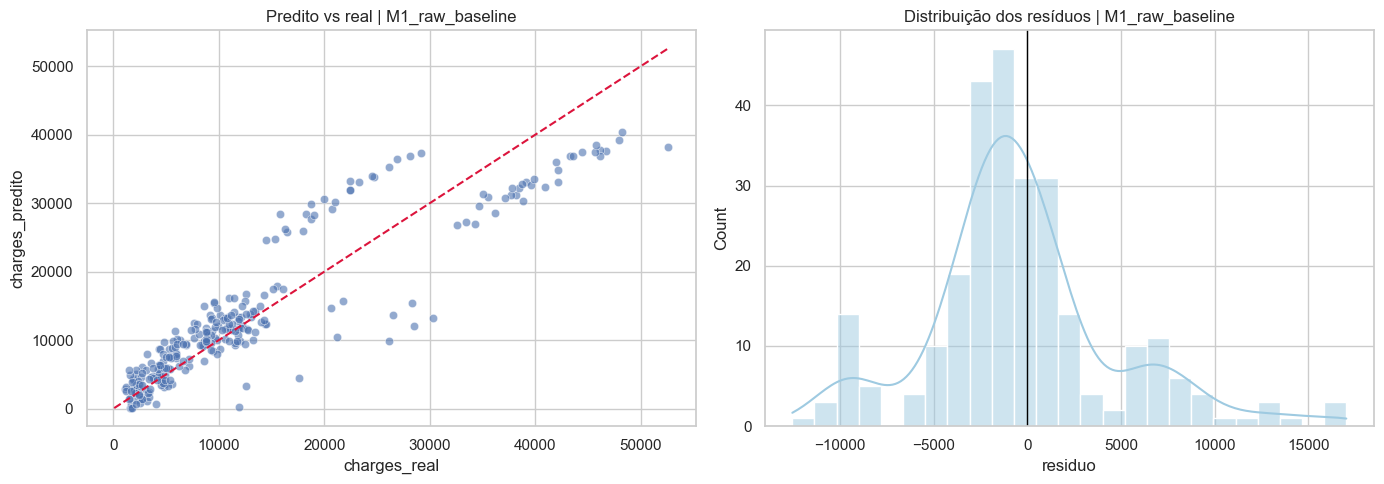

In [10]:
pred_best = best_result["pred_test"].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=pred_best, x="charges_real", y="charges_predito", alpha=0.6, ax=axes[0])
min_v = min(pred_best["charges_real"].min(), pred_best["charges_predito"].min())
max_v = max(pred_best["charges_real"].max(), pred_best["charges_predito"].max())
axes[0].plot([min_v, max_v], [min_v, max_v], linestyle="--", color="crimson")
axes[0].set_title(f"Predito vs real | {best_model_name}")

sns.histplot(pred_best["residuo"], kde=True, ax=axes[1], color="#9ecae1", edgecolor="white")
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_title(f"Distribuição dos resíduos | {best_model_name}")

plt.tight_layout()
plt.show()

- o modelo baseline (`M1_raw_baseline`) captura bem a tendência geral dos dados
- nos extremos, aparecem erros maiores, para alguns casos de custo alto, o modelo tende a subestimar (resíduo positivo), e em parte dos casos de custo baixo/médio há superestimação (resíduo negativo)
- a distribuição dos resíduos está relativamente centrada perto de 0, mas com caudas visíveis (principalmente à direita), sugerindo que ainda há padrões não explicados pelo baseline simples

,feature,coef,beta_padronizado,importance_pct
2,bmi,308.6324,0.1548,12.4505
1,age,259.0895,0.3000,24.1282
3,smoker_yes,"23,696.6607",0.7885,63.4213


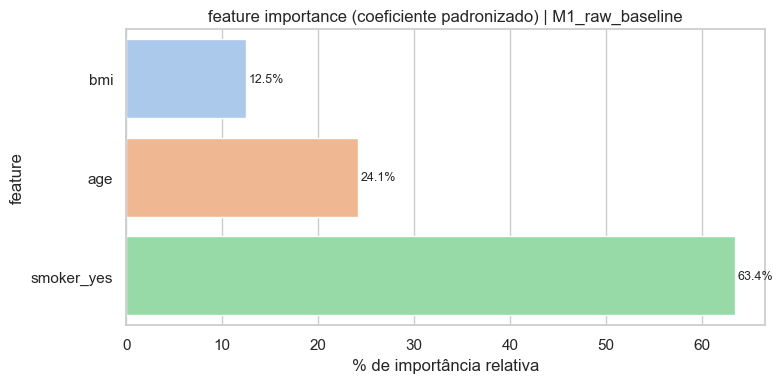

In [11]:
# importância de features por coeficiente padronizado (linear)
ols = best_result["ols"]

# matriz de design que o statsmodels realmente usou
X_design = pd.DataFrame(ols.model.exog, columns=ols.model.exog_names)
y_train_model = pd.Series(ols.model.endog, name="target")

coef_table = pd.DataFrame({
    "feature": ols.params.index,
    "coef": ols.params.values
})

# remove intercepto
coef_table = coef_table[coef_table["feature"] != "Intercept"].copy()

# beta padronizado = coef * (std_x / std_y)
std_x = X_design.std(ddof=0)
std_y = y_train_model.std(ddof=0)

coef_table["beta_padronizado"] = coef_table["coef"] * (
    std_x.reindex(coef_table["feature"]).values / std_y
)

coef_table["importance"] = coef_table["beta_padronizado"].abs()
coef_table["importance_pct"] = 100 * coef_table["importance"] / coef_table["importance"].sum()
coef_table = coef_table.sort_values("importance", ascending=True)

display(coef_table[["feature", "coef", "beta_padronizado", "importance_pct"]].round(4))

plt.figure(figsize=(8, 4))
ax = sns.barplot(data=coef_table, x="importance_pct", y="feature", palette="pastel")
ax.set_title(f"feature importance (coeficiente padronizado) | {best_model_name}")
ax.set_xlabel("% de importância relativa")
ax.set_ylabel("feature")

for i, row in coef_table.reset_index(drop=True).iterrows():
    ax.text(row["importance_pct"] + 0.3, i, f"{row['importance_pct']:.1f}%", va="center", fontsize=9)

plt.tight_layout()
plt.show()
